# ASTR 19 FINAL PROJECT

Importing everything

In [3]:
import numpy as np
import sep

In [4]:
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

Reading the image into a 2-d numpy array

In [5]:
with fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits") as hdul:
    hdul.info()  # Check the structure of the FITS file
    data = hdul[0].data  # Extract the data array
    
#Convert the data array to native byte order
if data is not None:
    data = data.byteswap().newbyteorder()

Filename: hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (3600, 3600)   float32   


Show the image

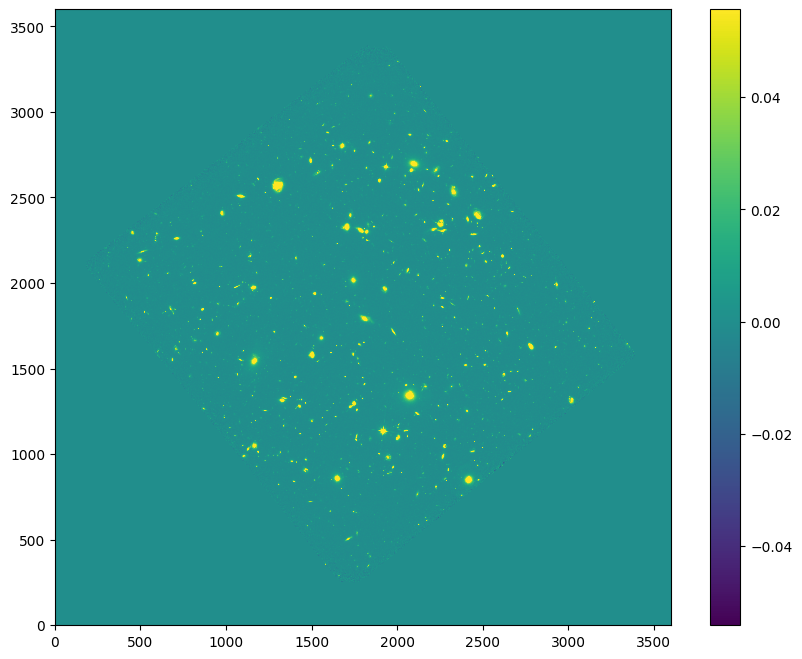

In [151]:
m, s = np.mean(data), np.std(data)  #Calculate mean and standard deviation for scaling

plt.imshow(data, interpolation='nearest', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()

plt.savefig("ASTR_Final_Project_Step#5_Image#1.png")

Measure the background

In [152]:
bkg = sep.Background(data)

In [153]:
#get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [154]:
#evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()

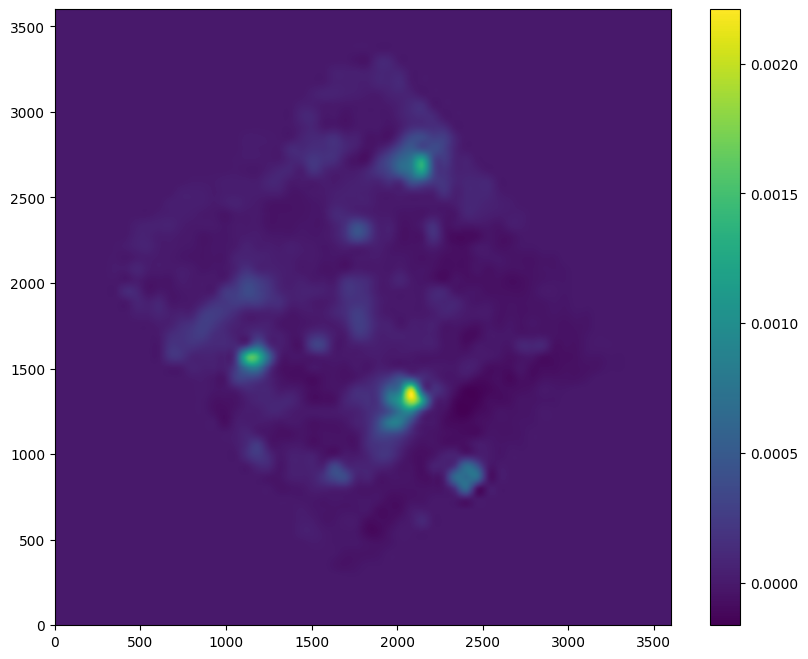

In [155]:
#show the background
plt.imshow(bkg_image, interpolation='nearest', origin='lower')
plt.colorbar();

plt.savefig("ASTR_Final_Project_Step#5_Image#2.png")

In [156]:
#evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

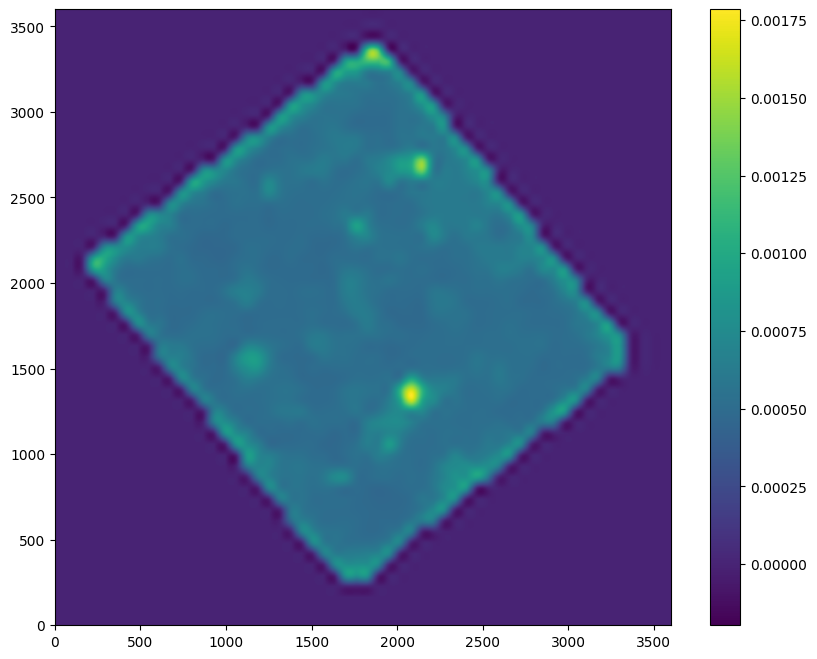

In [157]:
#show the background noise
plt.imshow(bkg_rms, interpolation='nearest', origin='lower')
plt.colorbar();

plt.savefig("ASTR_Final_Project_Step#5_Image#3.png")

Subtract the background

In [158]:
data_sub = data - bkg

Extract objects from the background-subtracted data

In [159]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

How many objects were detected

In [160]:
len(objects)

8643

Overlay objects and draw ellipes around them

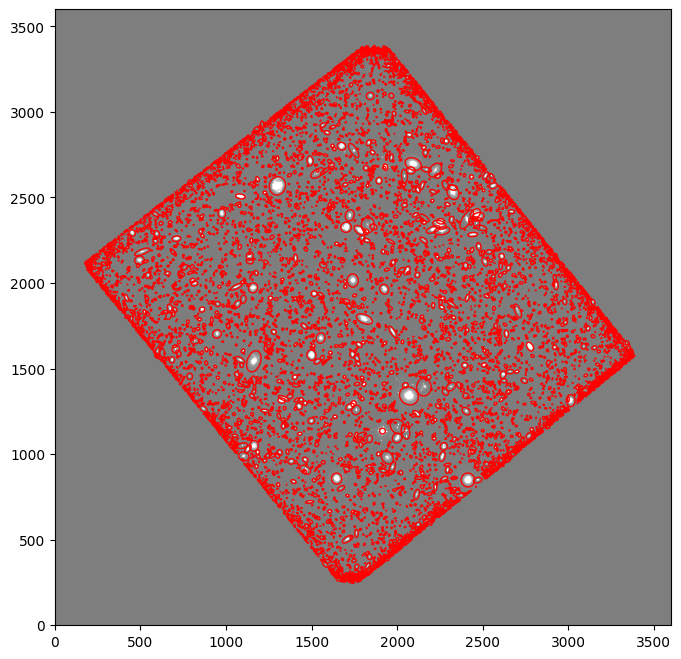

In [166]:
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

#plot ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)
    
plt.savefig("ASTR_Final_Project_Step#5_Image#4.png")

Aperture photometry

In [161]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

#show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.031282 +/- 0.176890
object 1: flux = 0.031018 +/- 0.176142
object 2: flux = -0.024388 +/- 0.002883
object 3: flux = 0.001947 +/- 0.044219
object 4: flux = 0.012457 +/- 0.111649
object 5: flux = -0.011228 +/- 0.002875
object 6: flux = 0.029368 +/- 0.171394
object 7: flux = -0.009126 +/- 0.002875
object 8: flux = 0.048023 +/- 0.219161
object 9: flux = 0.027840 +/- 0.166877


Creating a Histogram for the fluxes

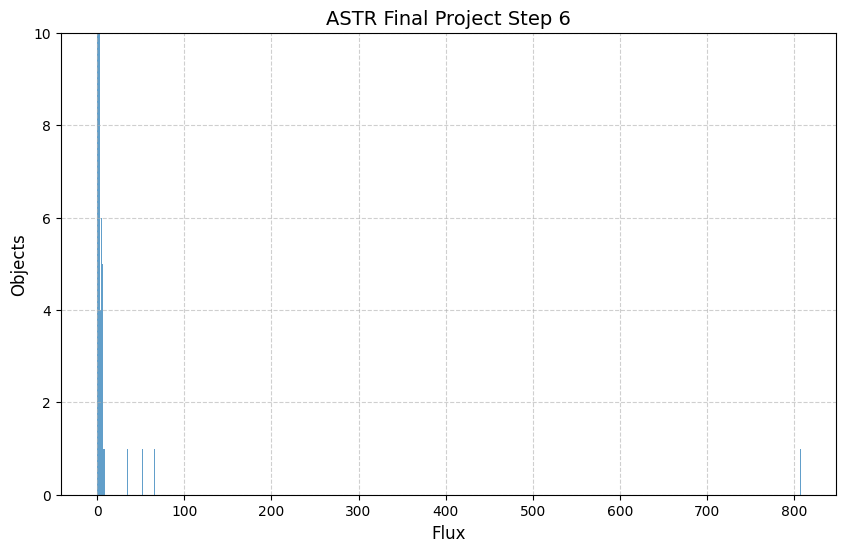

<Figure size 1000x800 with 0 Axes>

In [162]:
#adjusting dimensions of the plot
plt.figure(figsize=(10, 6))

#plotting everything
plt.hist(flux, bins=3000, alpha=0.7, )

#Set y-axis limit to 10 because pretty much all of them are around the same small values
plt.ylim(0, 10)

#adjusting labels, titles, and adding a grid
plt.xlabel("Flux", fontsize=12)
plt.ylabel("Objects", fontsize=12)
plt.title("ASTR Final Project Step 6", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

#show the plot
plt.show()

#saving the plot
plt.savefig("ASTR_19_Final_Project_Step#6.png")

Calculating the mean, median, and standard deviation of the distribution of fluxes

In [163]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
stan_dev_flux = np.std(flux)

print(f"Mean = {mean_flux}\nMedian = {median_flux}\nStandard Deviation = {stan_dev_flux}")

Mean = 0.3617466258281149
Median = 0.030954822942148894
Standard Deviation = 9.241925555851745


Calculating the largest outlier in the distribution, where it is on the image, and how many standard deviations it is from the mean

In [164]:
#finding the largest outlier
max_flux = np.max(data)

#where it is
outlier_position = np.where(data == max_flux)

#how many standard deviations it is from the mean
deviation_mean = (max_flux - mean_flux) / stan_dev_flux

print(f"Largest Outlier = {max_flux}\nPosition of Largest Outlier = {outlier_position}\nDeviation from Mean = {deviation_mean:.2f} standard deviations")

Largest Outlier = 74.44647979736328
Position of Largest Outlier = (array([1135]), array([1914]))
Deviation from Mean = 8.02 standard deviations


Making a 3-color false image of the UDF using RGB -> f160w, f125w, f105w

In [17]:
# Load FITS files
with fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f160w_v1.0_drz.fits") as red_hdul:
    red_f160w = red_hdul[0].data  # Red channel
with fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f125w_v1.0_drz.fits") as green_hdul:
    green_f125w = green_hdul[0].data  # Green channel
with fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits") as blue_hdul:
    blue_f105w = blue_hdul[0].data  # Blue channel

In [18]:
# Removing Background from each image
median_red = np.nanmedian(red_f160w[red_f160w<1])
median_green = np.nanmedian(green_f125w[green_f125w<1])
median_blue = np.nanmedian(blue_f105w[blue_f105w<1])
print(f"Median of red = {median_red}\nMedian of green = {median_green}\nMedian of blue = {median_blue}")

Median of red = 0.0
Median of green = 0.0
Median of blue = 0.0


In [19]:
red_f160w = red_f160w.byteswap().newbyteorder()
green_f125w = green_f125w.byteswap().newbyteorder()
blue_f105w = blue_f105w.byteswap().newbyteorder()

bkg_red = sep.Background(red_f160w)
bkg_green = sep.Background(green_f125w)
bkg_blue = sep.Background(blue_f105w)

red_f160w -= bkg_red
green_f125w -= bkg_green
blue_f105w -= bkg_blue

In [20]:
median_red = np.nanmedian(red_f160w[red_f160w<1])
median_green = np.nanmedian(green_f125w[green_f125w<1])
median_blue = np.nanmedian(blue_f105w[blue_f105w<1])
print(f"Median of red = {median_red}\nMedian of green = {median_green}\nMedian of blue = {median_blue}")

Median of red = 2.268324725663603e-21
Median of green = 7.127440320205985e-22
Median of blue = 1.293391096651404e-22


In [22]:
# Rescaling the data
def rescale_data(data, dmin = 0.01, dmax = 10.0):
    datac = np.clip(data, dmin, dmax)
    return (np.log10(datac) - np.log10(dmin))/(np.log10(dmax) - np.log10(dmin))

In [23]:
# Rescaled versions of the data for plotting
p_red = rescale_data(red_f160w)
p_green = rescale_data(green_f125w)
p_blue = rescale_data(blue_f105w)

In [24]:
# Making the RGB stack of the data
rgb = np.stack([p_red,0.7*p_green,p_blue],axis =-1)
print(rgb.shape)

(3600, 3600, 3)


[W 2024-12-10 11:27:09,306.306 matplotlib.image] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


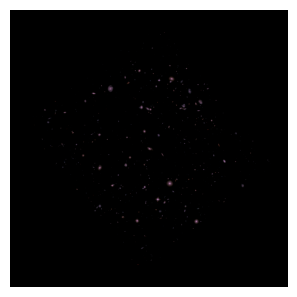

In [30]:
# Showing the data
xsize = rgb.shape[1]
ysize = rgb.shape[0]

f,ax = plt.subplots(1,1,figsize=(xsize/1000.0,ysize/1000.0))
ax.axis('off')
ax.imshow(rgb,origin='lower')